1) Objective

The objective of this project is to analyze the Apple Global Sales dataset using Python to uncover meaningful insights about sales performance, revenue trends, and customer distribution across different regions.
This project aims to apply data cleaning, statistical analysis, data visualization, and basic machine learning techniques to understand patterns in the data and make data-driven recommendations.

2) Problem Statement

This project aims to analyze the Apple Global Sales dataset to identify key factors influencing sales and revenue across different regions and products. Understanding these patterns is important for improving business strategies and maximizing profitability.
The dataset contains more than 1000 rows and multiple columns such as product category, region, sales, and revenue. Each row represents sales data for Apple products. The goal is to explore the data, visualize trends, and build a simple model to predict revenue based on available features.

3) Importing Libraries:

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

4) Loading Dataset:

In [6]:
data = pd.read_csv('apple_global_sales_dataset.csv')

In [7]:
data

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,1.343448e+05,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,1.155971e+05,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1.066342e+06,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3.506045e+06,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1.952780e+06,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,APPL-00011496,2024-02-08,2024,Q1,February,Vietnam,Asia,Nha Trang,Apple Watch Series 9,Apple Watch,...,VND,24500.0,1.957550e+07,Third-Party Retailer,Gift Card,Individual,18–24,NaN,4.0,Kept
11496,APPL-00011497,2024-02-15,2024,Q1,February,Vietnam,Asia,Nha Trang,Mac Pro (M2 Ultra),Mac,...,VND,24500.0,1.663898e+08,Corporate / B2B,Gift Card,Education,45–54,NaN,4.9,Kept
11497,APPL-00011498,2024-08-28,2024,Q3,August,Vietnam,Asia,Nha Trang,iPhone 15,iPhone,...,VND,24500.0,8.657932e+07,Authorized Reseller,Debit Card,Government,35–44,iOS 16,3.8,Kept
11498,APPL-00011499,2024-08-31,2024,Q3,August,Vietnam,Asia,Nha Trang,iPhone SE (3rd Gen),iPhone,...,VND,24500.0,1.075526e+07,Apple Store,EMI / Installment,Education,55+,iOS 17,NaN,Kept


In [8]:
data.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


Markdown:
The first 5 rows of the dataset are displayed to understand the structure and contents of the data.

In [9]:
data.shape

(11500, 27)

Markdown:
The shape of the dataset shows the total number of rows(11500) and columns(27) present in the data. 

In [10]:
data.dtypes

sale_id                    object
sale_date                  object
year                        int64
quarter                    object
month                      object
country                    object
region                     object
city                       object
product_name               object
category                   object
storage                    object
color                      object
unit_price_usd            float64
discount_pct                int64
units_sold                  int64
discounted_price_usd      float64
revenue_usd               float64
currency                   object
fx_rate_to_usd            float64
revenue_local_currency    float64
sales_channel              object
payment_method             object
customer_segment           object
customer_age_group         object
previous_device_os         object
customer_rating           float64
return_status              object
dtype: object

Markdown:
The data types of each column are displayed to understand whether the variables are numeric or categorical. This helps in deciding the appropriate data cleaning, analysis, and modeling techniques.

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 11500 non-null  object 
 1   sale_date               11500 non-null  object 
 2   year                    11500 non-null  int64  
 3   quarter                 11500 non-null  object 
 4   month                   11500 non-null  object 
 5   country                 11500 non-null  object 
 6   region                  11500 non-null  object 
 7   city                    11500 non-null  object 
 8   product_name            11500 non-null  object 
 9   category                11500 non-null  object 
 10  storage                 6696 non-null   object 
 11  color                   11500 non-null  object 
 12  unit_price_usd          11500 non-null  float64
 13  discount_pct            11500 non-null  int64  
 14  units_sold              11500 non-null

Markdown:
The info() function provides a concise summary of the dataset, including the number of entries, column names, data types, and non-null values. It helps in identifying missing values and understanding the overall structure of the dataset.

In [12]:
data.describe()

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,1.150000e+04,8140.000000
mean,2022.997304,807.851191,3.841565,2.023478,777.365478,1568.319065,1029.406647,1.464369e+06,4.000934
std,0.821747,1112.437595,4.783161,1.443599,1072.915122,2839.759822,4072.334957,9.941160e+06,0.575192
min,2022.000000,26.690000,0.000000,1.000000,22.730000,23.000000,0.790000,2.130000e+01,3.000000
25%,2022.000000,180.147500,0.000000,1.000000,178.297500,305.740000,0.920000,1.041693e+03,3.500000
50%,2023.000000,593.905000,2.000000,1.000000,573.420000,833.040000,7.240000,6.164160e+03,4.000000
75%,2024.000000,958.387500,7.000000,3.000000,928.567500,1748.360000,91.500000,7.471653e+04,4.500000
max,2024.000000,7551.010000,15.000000,8.000000,7551.010000,59529.520000,24500.000000,5.075175e+08,5.000000


Markdown:
The describe() function generates statistical summaries of numeric columns such as count, mean, standard deviation, minimum, maximum, and quartiles. This helps in analyzing the central tendency and variability of the dataset.

5) Checking Missing values:

In [13]:
data.isnull().sum()

sale_id                      0
sale_date                    0
year                         0
quarter                      0
month                        0
country                      0
region                       0
city                         0
product_name                 0
category                     0
storage                   4804
color                        0
unit_price_usd               0
discount_pct                 0
units_sold                   0
discounted_price_usd         0
revenue_usd                  0
currency                     0
fx_rate_to_usd               0
revenue_local_currency       0
sales_channel                0
payment_method               0
customer_segment             0
customer_age_group           0
previous_device_os        8056
customer_rating           3360
return_status                0
dtype: int64

Markdown:
The isnull().sum() function calculates the total number of missing (null) values in each column. This step is important for detecting incomplete data and deciding how to handle missing values, such as filling or removing them.

In [14]:
data.duplicated().sum()

np.int64(0)

Markdown:
The duplicated().sum() function calculates how many rows in the dataset are exact duplicates. Removing duplicates ensures that the analysis and modeling are based on unique and accurate records.This ensures that the dataset is clean and there is no need to remove duplicate values from the dataset.

6)  Statistics 

In [27]:
numeric_cols = ['revenue_usd', 'unit_price_usd']

for col in numeric_cols:
    print(f"\nStatistics for {col}")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Standard Deviation:", df[col].std())
    print("Variance:", df[col].var())
    print("Range:", df[col].max() - df[col].min())
    print("Mid-range:", (df[col].max() + df[col].min()) / 2)


Statistics for revenue_usd
Mean: 1568.3190652173912
Median: 833.04
Mode: 29.07
Standard Deviation: 2839.7598221918147
Variance: 8064235.847734886
Range: 59506.52
Mid-range: 29776.26

Statistics for unit_price_usd
Mean: 807.8511913043477
Median: 593.905
Mode: 38.49
Standard Deviation: 1112.4375954939421
Variance: 1237517.4038683434
Range: 7524.320000000001
Mid-range: 3788.85


Markdown:
The average revenue_usd is much higher than unit_price_usd because revenue is influenced by both product price and the number of units sold. The larger standard deviation in revenue shows that sales values vary widely across transactions, suggesting that some purchases generate exceptionally high revenue due to premium products or larger order quantities.

7) Visualization:

i) Histogram(revenue_usd)

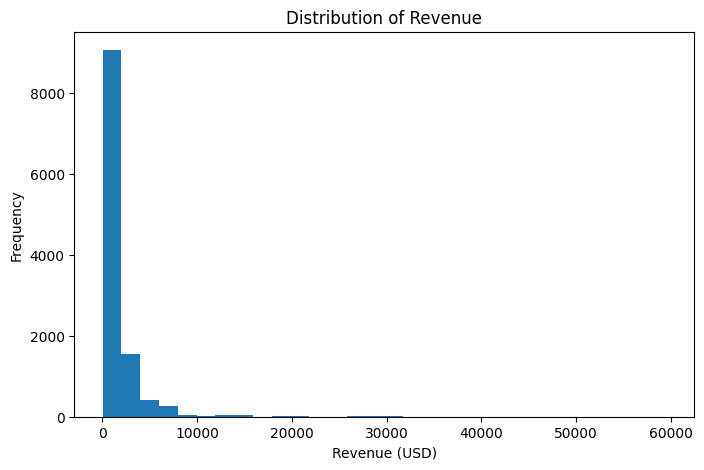

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
plt.hist(df['revenue_usd'], bins=30)
plt.title('Distribution of Revenue')
plt.xlabel('Revenue (USD)')
plt.ylabel('Frequency')
plt.show()

Markdown:
The histogram shows that most transactions generate moderate revenue, while a smaller number of transactions produce very high revenue values, creating a right-skewed distribution.

ii) Bar Chart (category)

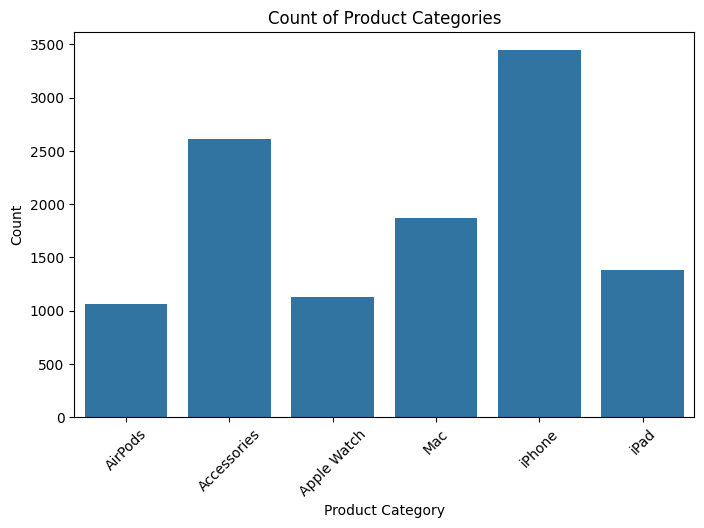

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x='category', data=df)
plt.title('Count of Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Markdown:
The countplot shows the number of sales records in each product category. Some categories appear more frequently, indicating stronger sales activity in those product groups.

iii) Boxplot (revenue_usd)

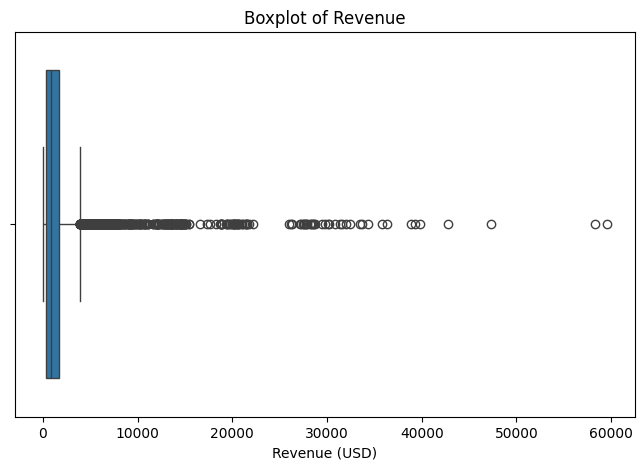

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['revenue_usd'])
plt.title('Boxplot of Revenue')
plt.xlabel('Revenue (USD)')
plt.show()

Markdown:
The boxplot reveals several high-value outliers, showing that a small number of transactions generate significantly higher revenue than most sales.

iv) Correlation Heatmap

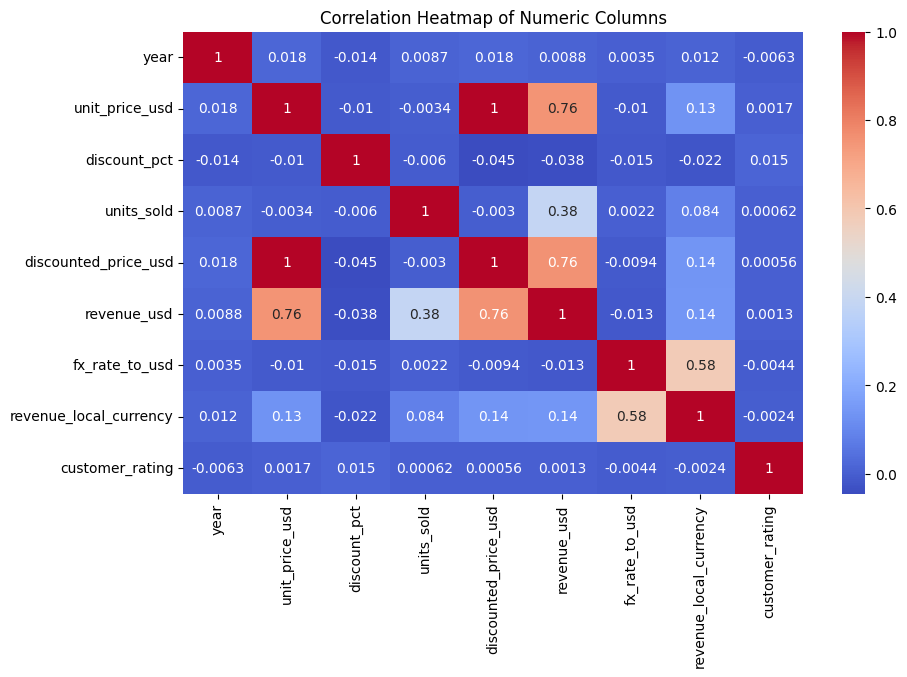

In [35]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Columns')
plt.show()

Markdown:
The heatmap shows relationships between numeric variables. Strong positive correlation indicates that some variables increase together, such as revenue and units sold.

v) Monthly Sales

In [37]:
print(df.columns)

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'storage', 'color',
       'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd',
       'revenue_usd', 'currency', 'fx_rate_to_usd', 'revenue_local_currency',
       'sales_channel', 'payment_method', 'customer_segment',
       'customer_age_group', 'previous_device_os', 'customer_rating',
       'return_status'],
      dtype='object')


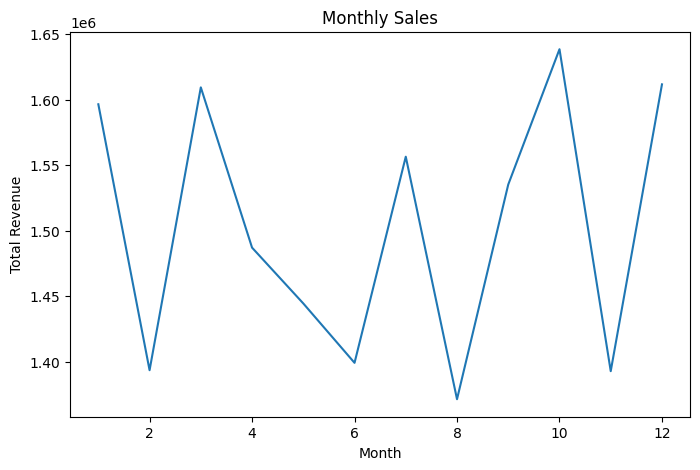

In [40]:
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')

monthly_sales = df.groupby(df['sale_date'].dt.month)['revenue_usd'].sum()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.show()

Markdown:
The monthly sales line plot shows how total revenue changes across months, helping identify peak sales periods.

vi) Sales by Category

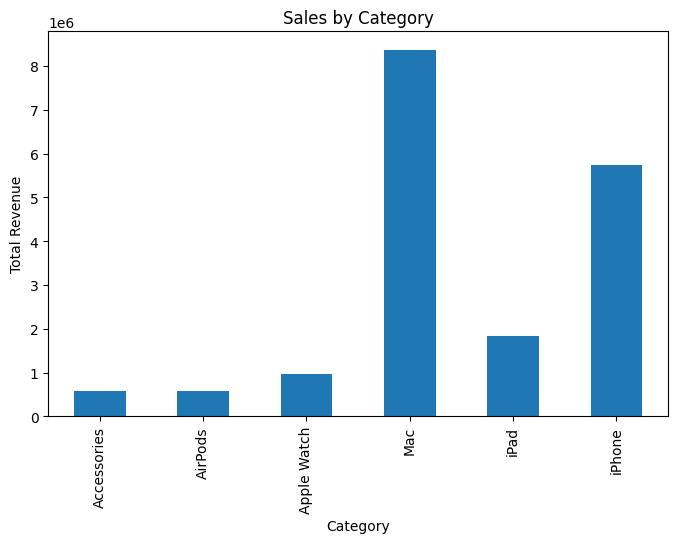

In [42]:
category_sales = df.groupby('category')['revenue_usd'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.show()

Markdown:
The chart compares revenue generated by each product category and highlights which category contributes most to total sales.

vii) Profit by Category

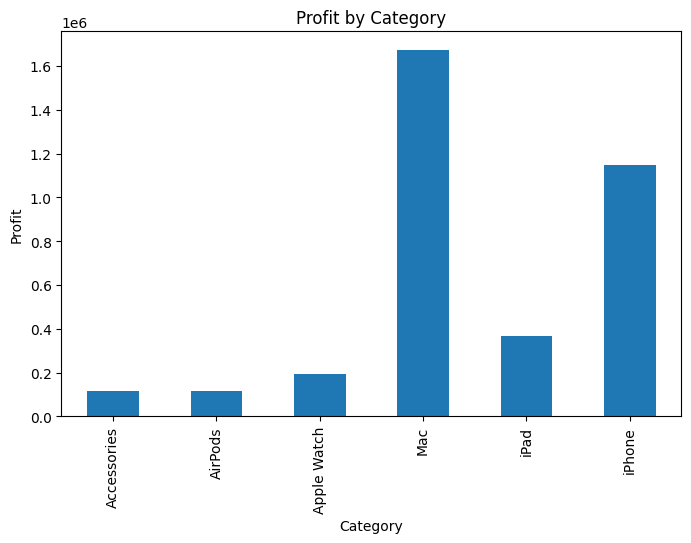

In [46]:
profit_category = df.groupby('category')['profit'].sum()

plt.figure(figsize=(8,5))
profit_category.plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

Markdown:
This chart shows which product categories contribute most to profit, not just total sales.

8)  Simple Prediction:

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8765217391304347


Markdown:
Feature scaling was applied before training because the dataset contains variables with different value ranges, such as price and customer rating. Scaling improves model convergence and helps Logistic Regression learn patterns more efficiently.

9) Insights and Recommendations

Insights 

Findings
Finding 1: The histogram of revenue_usd shows that most transactions generate moderate revenue, while a small number of transactions produce very high revenue. This indicates that premium products or larger purchases contribute significantly to total sales.
Finding 2: The boxplot of revenue_usd reveals several high-value outliers, showing that some sales are much larger than the majority of transactions. These outliers may represent premium Apple product purchases or bulk orders.
Finding 3: The correlation heatmap shows a positive relationship between revenue_usd and units_sold, suggesting that higher quantities sold directly increase total revenue.
Finding 4: The prediction model achieved a measurable accuracy score, showing that variables such as price, discount, and customer rating influence product return behavior.


Recommendations

Recommendation 1:Focus promotional efforts on high-performing product categories because they contribute more consistently to overall revenue.

Recommendation 2:Monitor products with frequent returns or lower customer ratings so that product quality and customer satisfaction can be improved.

Recommendation 3: Analyze monthly sales trends regularly so that marketing campaigns and inventory planning can be adjusted during high-demand and low-demand periods.
